<a href="https://colab.research.google.com/github/Purvajavenkatesh04/Purvaja-DS/blob/main/11239A075_EXERCISE_2_DSE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

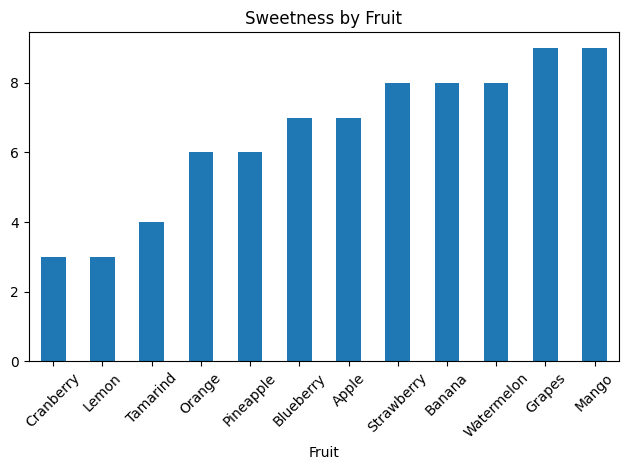

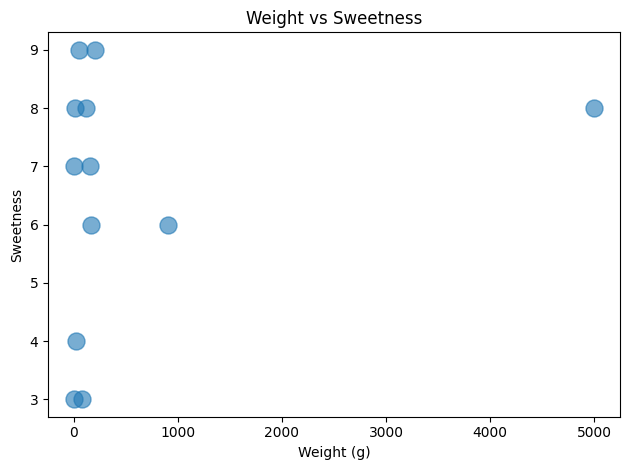

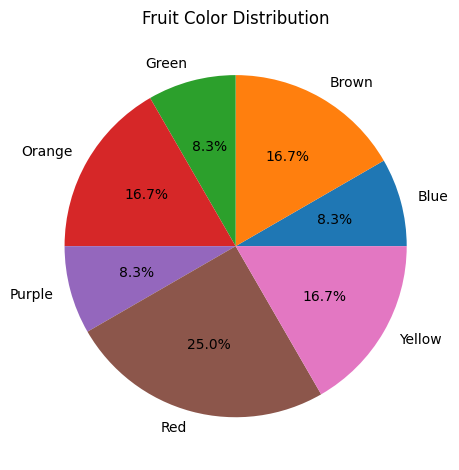

Average weight: 557.92
Average sweetness: 6.5
Mode of fruit color: Red

Sweetest fruit(s):
      Fruit  Sweetness
10  Grapes          9
11   Mango          9

Heaviest fruit(s):
         Fruit  Weight (g)
9  Watermelon        5000

Fruits under 100g and Sweetness > 5:
          Fruit  Weight (g)  Sweetness
5    Blueberry           2          7
7   Strawberry          15          8
10      Grapes          50          9

Average Sweetness by Color:
 Color
Blue      7.0
Brown     5.0
Green     8.0
Orange    7.5
Purple    9.0
Red       6.0
Yellow    5.5
Name: Sweetness, dtype: float64


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV
df = pd.read_csv('/content/fruits (1).csv')

# Rename column to remove special character (for easier use)
df.rename(columns={'Sweetness (1–10)': 'Sweetness'}, inplace=True)

# Sorting
sorted_by_weight = df.sort_values('Weight (g)')
sorted_by_sweetness = df.sort_values('Sweetness', ascending=False)

# Stats
df['Sweetness/Weight'] = df['Sweetness'] / df['Weight (g)']
avg_weight = df['Weight (g)'].mean()
avg_sweet = df['Sweetness'].mean()
mode_color = df['Color'].mode()[0]

# Grouping
grouped = df.groupby('Color')
color_counts = grouped.size()
avg_sweet_by_color = grouped['Sweetness'].mean()

# Visualizations
df.plot(x='Fruit', y='Sweetness', kind='bar', title='Sweetness by Fruit', legend=False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df.plot.scatter(x='Weight (g)', y='Sweetness', s=150, alpha=0.6, title='Weight vs Sweetness')
plt.tight_layout()
plt.show()

color_counts.plot.pie(autopct='%1.1f%%', title='Fruit Color Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Insights
sweetest = df[df['Sweetness'] == df['Sweetness'].max()]
heaviest = df[df['Weight (g)'] == df['Weight (g)'].max()]
light_sweet = df[(df['Weight (g)'] < 100) & (df['Sweetness'] > 5)]

# Print key findings
print("Average weight:", round(avg_weight, 2))
print("Average sweetness:", round(avg_sweet, 2))
print("Mode of fruit color:", mode_color)
print("\nSweetest fruit(s):\n", sweetest[['Fruit', 'Sweetness']])
print("\nHeaviest fruit(s):\n", heaviest[['Fruit', 'Weight (g)']])
print("\nFruits under 100g and Sweetness > 5:\n", light_sweet[['Fruit', 'Weight (g)', 'Sweetness']])
print("\nAverage Sweetness by Color:\n", avg_sweet_by_color.round(2))
